<a href="https://colab.research.google.com/github/luisenrique2610/Terminal-de-Economia/blob/main/Exposicion_CienciaDeDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DETECCION DE FRAUDES EN TARJETAS DE CREDITO

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
#df_fraud = pd.read_csv('/content/Fraudulent_E-Commerce_Transaction_Data.csv')
#df_fraud.head(5)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_fraud = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fraudulent_E-Commerce_Transaction_Data.csv')
df_fraud.head(5)


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [ ]:
df_fraud_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fraudulent_E-Commerce_Transaction_Data_Test.csv')
df_fraud_test.head(5)

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [ ]:
df_fraud.columns = ['ID de la transaccion', 'ID del cliente', 'Mon†o de la transaccion', 'Fecha de la transaccion', 'Metodo de pago', 'Categoria del producto', 'Cantidad', 'Edad del cliente','Localizacion del cliente', 'Dispositivo usado', 'Direccion IP', 'Direccion de envio', 'Direccion de facturacion', '¿Es fraudulenta?','Dias desde creacion de la cuenta', 'Hora de la transaccion'] #Cambiar nombre de columnas
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Fecha de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora de la transaccion
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [ ]:
df_fraud_test.columns = ['ID de la transaccion', 'ID del cliente', 'Mon†o de la transaccion', 'Fecha de la transaccion', 'Metodo de pago', 'Categoria del producto', 'Cantidad', 'Edad del cliente','Localizacion del cliente', 'Dispositivo usado', 'Direccion IP', 'Direccion de envio', 'Direccion de facturacion', '¿Es fraudulenta?','Dias desde creacion de la cuenta', 'Hora de la transaccion'] #Cambiar nombre de columnas
df_fraud_test.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Fecha de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora de la transaccion
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [ ]:
df_fraud.shape

(1472952, 16)

In [ ]:
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 16 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   ID de la transaccion              1472952 non-null  object 
 1   ID del cliente                    1472952 non-null  object 
 2   Mon†o de la transaccion           1472952 non-null  float64
 3   Fecha de la transaccion           1472952 non-null  object 
 4   Metodo de pago                    1472952 non-null  object 
 5   Categoria del producto            1472952 non-null  object 
 6   Cantidad                          1472952 non-null  int64  
 7   Edad del cliente                  1472952 non-null  int64  
 8   Localizacion del cliente          1472952 non-null  object 
 9   Dispositivo usado                 1472952 non-null  object 
 10  Direccion IP                      1472952 non-null  object 
 11  Direccion de envio                147

In [ ]:
df_fraud.describe().T

,count,mean,std,min,25%,50%,75%,max
Mon†o de la transaccion,1472952.0,226.768309,270.395099,10.0,68.61,151.76,296.05,12701.75
Cantidad,1472952.0,3.000230,1.414736,1.0,2.00,3.00,4.00,5.00
Edad del cliente,1472952.0,34.512081,10.003134,-16.0,28.00,35.00,41.00,86.00
¿Es fraudulenta?,1472952.0,0.050129,0.218212,0.0,0.00,0.00,0.00,1.00
Dias desde creacion de la cuenta,1472952.0,179.646398,106.864223,1.0,86.00,179.00,272.00,365.00
Hora de la transaccion,1472952.0,11.286964,6.975995,0.0,5.00,11.00,17.00,23.00


In [ ]:
df_fraud.describe(include='object')

,ID de la transaccion,ID del cliente,Fecha de la transaccion,Metodo de pago,Categoria del producto,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion
count,1472952,1472952,1472952,1472952,1472952,1472952,1472952,1472952,1472952,1472952
unique,1472952,1472952,1346684,4,5,99135,3,1472651,1472948,1472949
top,d1a811a2-6015-47fa-95e5-0a5282755932,637d5ed1-a4af-4234-a1d9-a3791b6f1bb6,2024-01-27 04:00:16,credit card,health & beauty,New Michael,mobile,62.29.103.68,USCGC Holmes\nFPO AA 56289,USNS Mills\nFPO AE 77203
freq,1,1,6,368429,295367,1258,491743,2,2,2


In [ ]:
df_fraud.isnull().sum()

,0
ID de la transaccion,0
ID del cliente,0
Mon†o de la transaccion,0
Fecha de la transaccion,0
Metodo de pago,0
Categoria del producto,0
Cantidad,0
Edad del cliente,0
Localizacion del cliente,0
Dispositivo usado,0


In [ ]:
import plotly.express as px
px.box(data_frame=df_fraud, x='Edad del cliente',width=500, height=300)

In [ ]:
def clean_data(df) -> pd.DataFrame:

  df["Fecha de la transaccion"] = pd.to_datetime(df["Fecha de la transaccion"])

  df["Dia de la transaccion"] = df["Fecha de la transaccion"].dt.day
  df["Mes de la transaccion"] = df["Fecha de la transaccion"].dt.month
  df["Dia de la semana de la transaccion"] = df["Fecha de la transaccion"].dt.day_of_week

  mean_values = np.round(df['Edad del cliente'].mean(),0)
  df['Edad del cliente'] = np.where(df['Edad del cliente'] <= -9,
                                    np.abs(df['Edad del cliente']),
                                    df['Edad del cliente'])

  df['Edad del cliente'] = np.where(df['Edad del cliente'] < 9,
                                   mean_values,
                                    df['Edad del cliente'])

  df["Coincide la direccion de envio y facturacion"] = (df["Direccion de envio"] == df["Direccion de facturacion"]).astype(int)

  df.drop(columns=["ID de la transaccion", "ID del cliente", "Localizacion del cliente",
                   "Direccion IP", "Fecha de la transaccion", "Direccion de envio", "Direccion de facturacion"], inplace=True)

  int_col = df.select_dtypes(include="int").columns
  float_col = df.select_dtypes(include="float").columns

  df[int_col] = df[int_col].apply(pd.to_numeric, downcast="integer")
  df[float_col] = df[float_col].apply(pd.to_numeric, downcast="float")

  return df

In [ ]:
df_fraud = clean_data(df_fraud)
df_fraud.head()

,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Dispositivo usado,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora de la transaccion,Dia de la transaccion,Mes de la transaccion,Dia de la semana de la transaccion,Coincide la direccion de envio y facturacion
0,58.090000,bank transfer,electronics,1,17.0,tablet,0,30,5,20,2,1,1
1,389.959991,debit card,electronics,2,40.0,desktop,0,72,8,25,2,6,1
2,134.190002,PayPal,home & garden,2,22.0,tablet,0,63,3,18,3,0,1
3,226.169998,bank transfer,clothing,5,31.0,desktop,0,124,20,16,3,5,1
4,121.529999,bank transfer,clothing,2,51.0,tablet,0,158,5,15,1,0,1


In [ ]:
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 13 columns):
 #   Column                                        Non-Null Count    Dtype  
---  ------                                        --------------    -----  
 0   Mon†o de la transaccion                       1472952 non-null  float32
 1   Metodo de pago                                1472952 non-null  object 
 2   Categoria del producto                        1472952 non-null  object 
 3   Cantidad                                      1472952 non-null  int8   
 4   Edad del cliente                              1472952 non-null  float32
 5   Dispositivo usado                             1472952 non-null  object 
 6   ¿Es fraudulenta?                              1472952 non-null  int8   
 7   Dias desde creacion de la cuenta              1472952 non-null  int16  
 8   Hora de la transaccion                        1472952 non-null  int8   
 9   Dia de la transaccion              

<Axes: xlabel='Mon†o de la transaccion', ylabel='Count'>

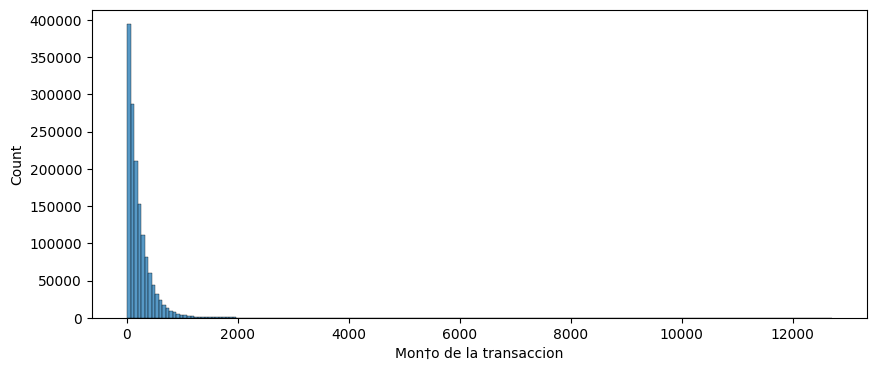

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(df_fraud['Mon†o de la transaccion'], bins=200)

/tmp/ipython-input-2147944898.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




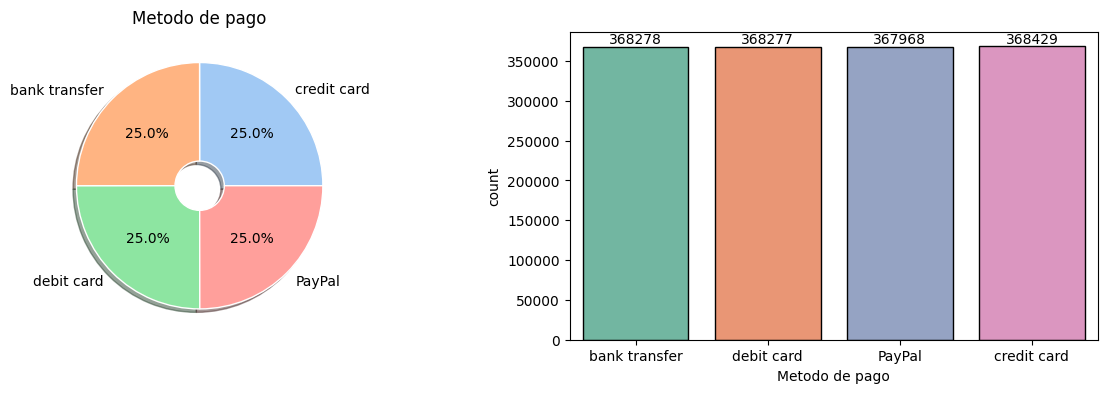

In [ ]:
payment_count = df_fraud["Metodo de pago"].value_counts()
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.set_palette('pastel')
colors = sns.color_palette()
plt.pie(payment_count,labels = payment_count.index,shadow=True,autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8,edgecolor="w"))
plt.title("Metodo de pago")

plt.subplot(1,2,2)

ax = sns.countplot(data=df_fraud,x="Metodo de pago",edgecolor="black",linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)

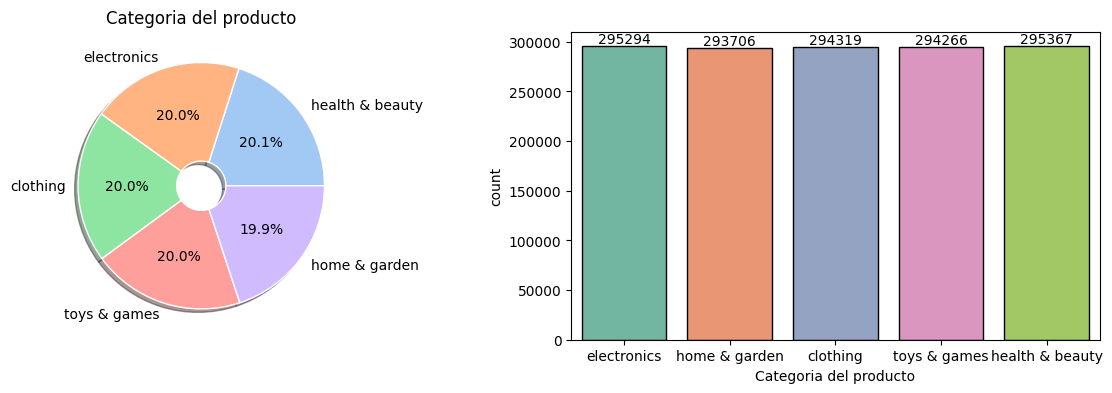

In [ ]:
payment_count = df_fraud["Categoria del producto"].value_counts()
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.set_palette('pastel')
colors = sns.color_palette()
plt.pie(payment_count,labels = payment_count.index,shadow=True,autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8,edgecolor="w"))
plt.title("Categoria del producto")

plt.subplot(1,2,2)

ax = sns.countplot(data=df_fraud,x="Categoria del producto",edgecolor="black",linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)

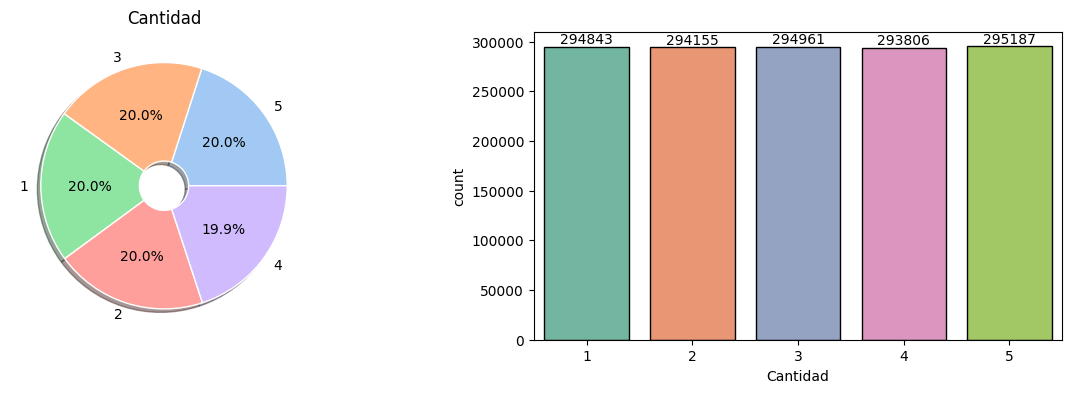

In [ ]:
quantity_count = df_fraud["Cantidad"].value_counts()
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.set_palette('pastel')
colors = sns.color_palette()
plt.pie(quantity_count,labels = quantity_count.index,shadow=True,autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8,edgecolor="w"))
plt.title("Cantidad")

plt.subplot(1,2,2)

ax = sns.countplot(data=df_fraud,x="Cantidad",edgecolor="black",linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)

<Axes: xlabel='Edad del cliente', ylabel='Count'>

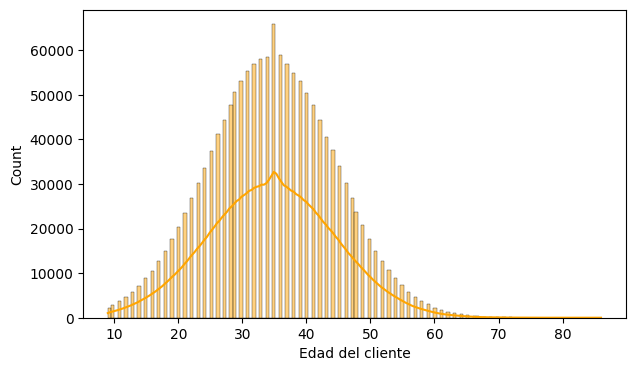

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(data=df_fraud, x="Edad del cliente",bins=150,kde=True,color='orange')

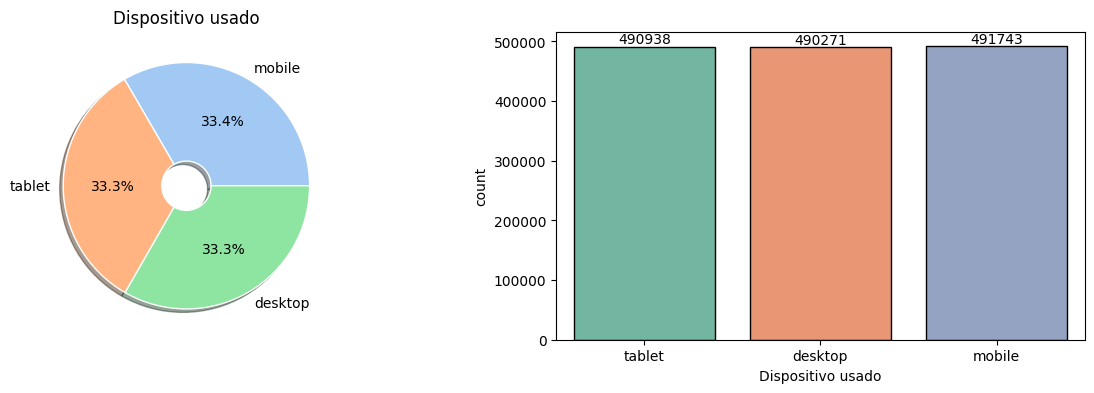

In [ ]:
device_count = df_fraud["Dispositivo usado"].value_counts()
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.set_palette('pastel')
colors = sns.color_palette()
plt.pie(device_count,labels = device_count.index,shadow=True,autopct='%1.1f%%',
        colors=colors,
        wedgeprops=dict(width=0.8,edgecolor="w"))
plt.title("Dispositivo usado")

plt.subplot(1,2,2)

ax = sns.countplot(data=df_fraud,x="Dispositivo usado",edgecolor="black",linewidth=1, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)

<Axes: xlabel='Dias desde creacion de la cuenta', ylabel='Count'>

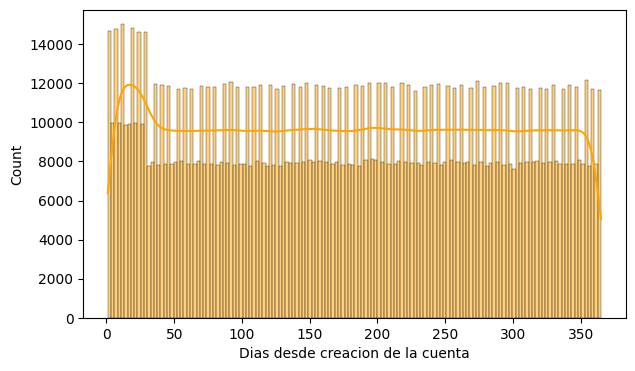

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(data=df_fraud, x="Dias desde creacion de la cuenta",bins=150,kde=True,color='orange')

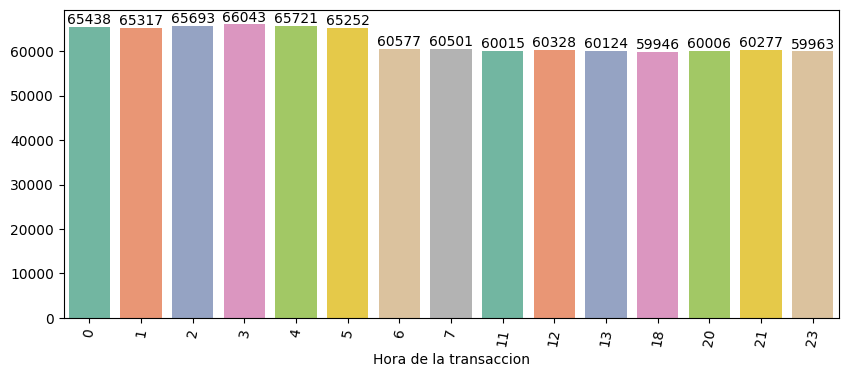

In [ ]:
hour_count = df_fraud["Hora de la transaccion"].value_counts().head(15)

plt.figure(figsize=(10,4))
sns.set_palette('Set2')
colors = sns.color_palette()
ax=sns.barplot(x=hour_count.index, y=hour_count.values,palette=colors)
plt.xticks(rotation=80)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

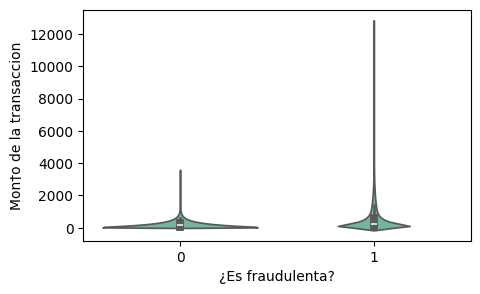

In [ ]:
plt.figure(figsize=(5,3))
sns.violinplot(data=df_fraud, x='¿Es fraudulenta?', y='Mon†o de la transaccion')
plt.show()

In [ ]:
column = ['Metodo de pago', 'Categoria del producto',
          'Cantidad','Dispositivo usado',
          'Dia de la semana de la transaccion', 'Mes de la transaccion',
          'Coincide la direccion de envio y facturacion']

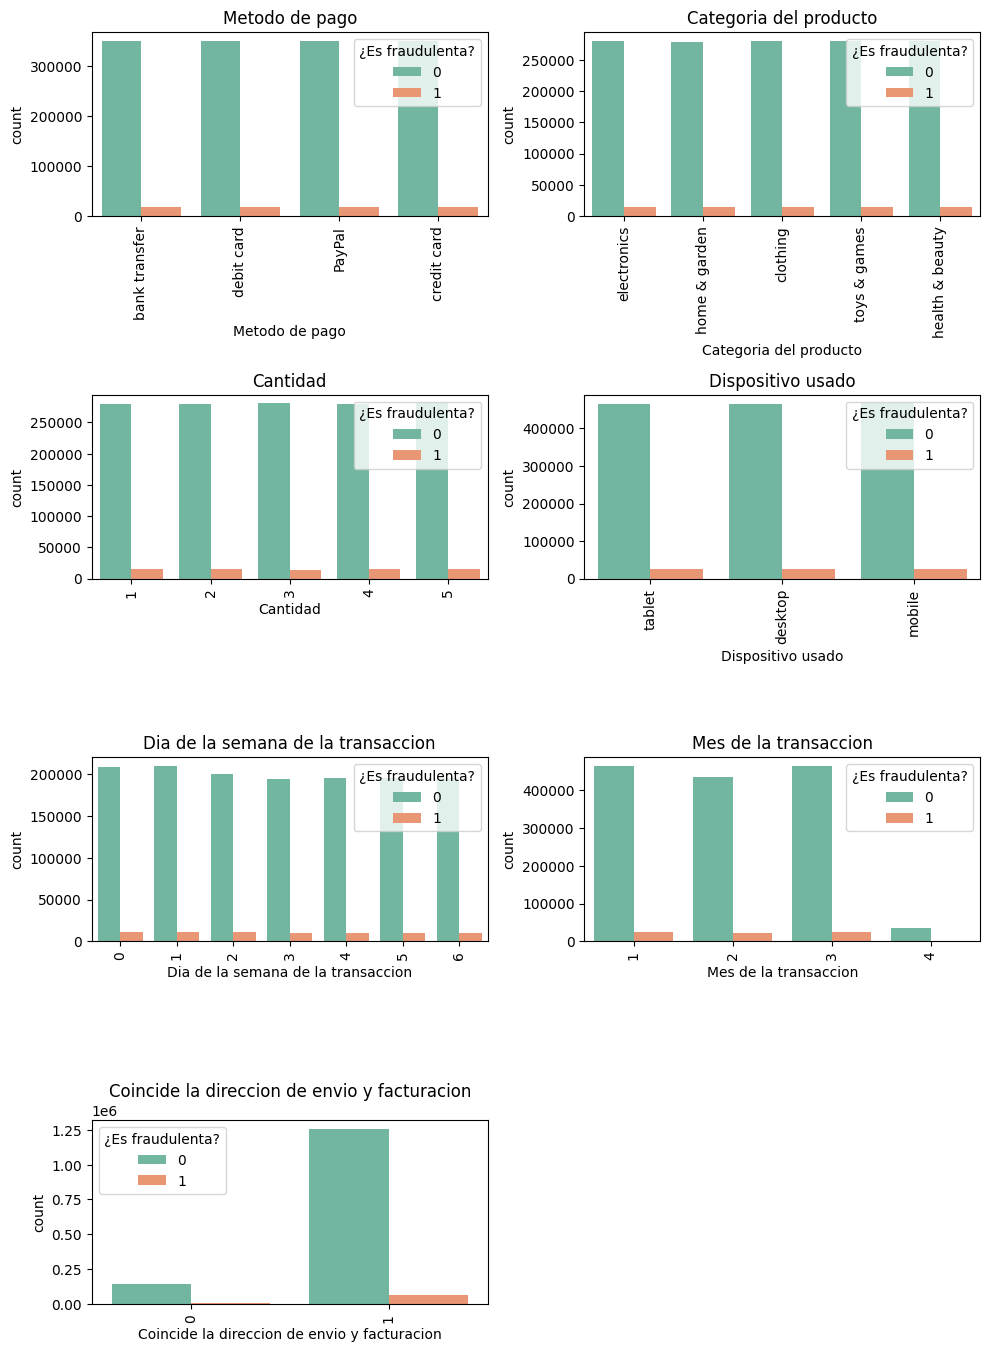

In [ ]:
plt.figure(figsize=(10,35))
plot_num = 1
for col in column:
    plt.subplot(10,2,plot_num)
    sns.countplot(data=df_fraud, x=col, hue="¿Es fraudulenta?")
    plt.xticks(rotation=90)
    plt.title(col)
    plt.tight_layout()
    plot_num += 1

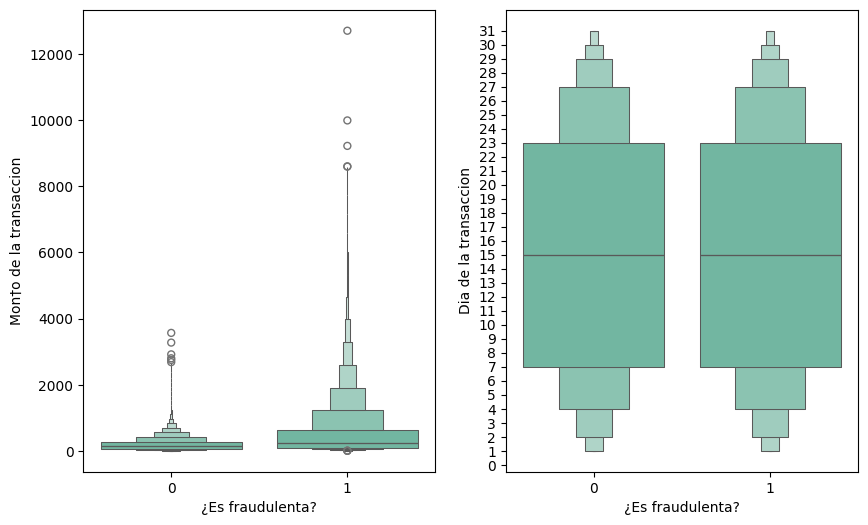

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.boxenplot(x='¿Es fraudulenta?', y='Mon†o de la transaccion', data=df_fraud)
plt.subplot(1,2,2)
sns.boxenplot(x='¿Es fraudulenta?', y='Dia de la transaccion', data=df_fraud)
plt.yticks(np.arange(0,32))
plt.show()

In [ ]:
## Train Data
train_data = df_fraud.drop(columns=["¿Es fraudulenta?"])
train_label = df_fraud["¿Es fraudulenta?"]

## Test Data
clean_test_df = clean_data(df_fraud_test)
test_data = clean_test_df.drop(columns=["¿Es fraudulenta?"])
test_label = clean_test_df["¿Es fraudulenta?"]

In [ ]:
cat_col = train_data.select_dtypes(include="O").columns
num_col = []
for col in train_data.columns:
    if col not in cat_col  and col != 'Is Address Match':
        num_col.append(col)

In [ ]:
transformer = ColumnTransformer(transformers=[
    ('encoding',OneHotEncoder(),cat_col),
    ('scaling',StandardScaler(),num_col)
],remainder='passthrough')

In [ ]:
classifiers = {
    "Regresion logistica" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
}

In [ ]:
def plot_confusion_matrix(cm, labels):
    fig_cm = px.imshow(cm, labels=dict(x="Predicted", y="Actual", color="Count"),
                       x=labels, y=labels, color_continuous_scale='Viridis', text_auto = True,
                       title="Confusion Matrix")
    fig_cm.update_layout(coloraxis_showscale=False)
    fig_cm.show()

In [ ]:
classifier_name = []
accuracy = []
for name, classifier in classifiers.items():

    model = Pipeline(steps=[
        ('transformer',transformer),
        ('classifier',classifier)
    ])

    start_time = time.time()

    model.fit(train_data, train_label)

    training_time = time.time() - start_time

    test_pred = model.predict(test_data)


    ## Evaluate Model

    acc_score = accuracy_score(test_label, test_pred)
    conf_mat = confusion_matrix(test_label, test_pred)
    class_report = classification_report(test_label, test_pred)
    print(f"Nombre del modelo : {name}")
    print(f"Accuracy score : {acc_score}")
    print(f"Matriz de confusion : \n{conf_mat}")
    print(f"Reporte de clasificacion :\n{class_report}")
    print(f"{name} Training time: {training_time:.2f} seconds")
    print("="*55)

    classifier_name.append(name)
    accuracy.append(acc_score)

Nombre del modelo : Regresion logistica
Accuracy score : 0.9547636311298671
Matriz de confusion : 
[[1397891    1223]
 [  65408    8430]]
Reporte de clasificacion :
              precision    recall  f1-score   support

           0       0.96      1.00      0.98   1399114
           1       0.87      0.11      0.20     73838

    accuracy                           0.95   1472952
   macro avg       0.91      0.56      0.59   1472952
weighted avg       0.95      0.95      0.94   1472952

Regresion logistica Training time: 4.93 seconds
Nombre del modelo : Decision Tree
Accuracy score : 1.0
Matriz de confusion : 
[[1399114       0]
 [      0   73838]]
Reporte de clasificacion :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1399114
           1       1.00      1.00      1.00     73838

    accuracy                           1.00   1472952
   macro avg       1.00      1.00      1.00   1472952
weighted avg       1.00      1.00      1.00 

In [ ]:
lr_accuracy = accuracy_score(test_label, test_pred)
lr_accuracy

0.9999484029350583

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(train_data, train_label, train_size = 0.75,
                                                random_state = 31)

In [ ]:
modelo_LR = Pipeline(steps=[
    ('transformer', transformer),
    ('classifier', LogisticRegression(max_iter=1000))
]).fit(train_data, train_label)

modelo_LR

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoding', OneHotEncoder(),
                                                  Index(['Metodo de pago', 'Categoria del producto', 'Dispositivo usado'], dtype='object')),
                                                 ('scaling', StandardScaler(),
                                                  ['Mon†o de la transaccion',
                                                   'Cantidad',
                                                   'Edad del cliente',
                                                   'Dias desde creacion de la '
                                                   'cuenta',
                                                   'Hora de la transaccion',
                                                   'Dia de la transaccion',
                                                   'Mes de la transaccion',
                                                   'Dia de la semana de la '
                                                   'transaccion',
                                                   'Coincide la direccion de '
                                                   'envio y facturacion'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
pred = modelo_LR.predict(test_data)
pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int8)

In [ ]:
lr_accuracy = accuracy_score(test_label, pred)
lr_accuracy

0.9547636311298671

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
lr_precision = precision_score(test_label, pred)
lr_precision

0.8733036361752823

In [ ]:
lr_recall = recall_score(test_label, pred)
lr_recall

0.11416885614453262

In [ ]:
lr_f1 = f1_score(test_label, pred)
lr_f1

0.20193793342995053

In [ ]:
lr_report = classification_report(test_label, pred)
print(lr_report)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98   1399114
           1       0.87      0.11      0.20     73838

    accuracy                           0.95   1472952
   macro avg       0.91      0.56      0.59   1472952
weighted avg       0.95      0.95      0.94   1472952



In [ ]:
lr_cm = confusion_matrix(test_label, pred)
plot_confusion_matrix(lr_cm, ['No Fraude', 'Fraude'])

In [ ]:
TPrate = lr_cm[1,1] / (lr_cm[1,0] + lr_cm[1,1])
TPrate

np.float64(0.11416885614453262)

In [ ]:
FPrate = lr_cm[0,1]/(lr_cm[0,0] + lr_cm[0,1])
FPrate

np.float64(0.0008741246245838437)

In [ ]:
from sklearn.metrics import RocCurveDisplay

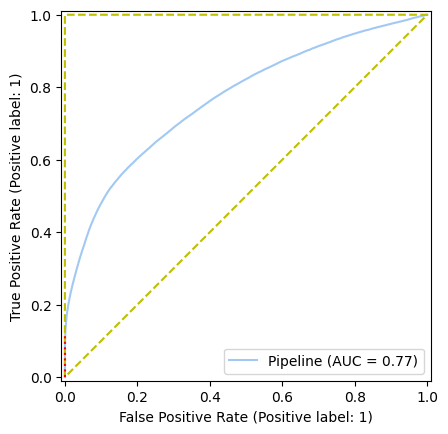

In [ ]:
RocCurveDisplay.from_estimator(modelo_LR, test_data, test_label)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.hlines(TPrate, 0, FPrate, colors = 'r', linestyles = 'dotted')
plt.vlines(FPrate, 0, TPrate, colors = 'r', linestyles = 'dotted')
plt.show()

In [ ]:
pred_proba = modelo_LR.predict_proba(test_data)
pred_proba

array([[0.91870457, 0.08129543],
       [0.89649279, 0.10350721],
       [0.90896012, 0.09103988],
       ...,
       [0.98455034, 0.01544966],
       [0.98651264, 0.01348736],
       [0.98528436, 0.01471564]])

In [ ]:
No_fraude = (test_label == 0)
Fraude = (test_label == 1)

pred_Nofraude = pred_proba[No_fraude][:,0]
pred_Fraude = pred_proba[Fraude][:,1]

In [ ]:
r0 = np.random.uniform(-0.3, 0.3, size = pred_Nofraude.shape[0])
r1 = np.random.uniform(0.7, 1.3, size = pred_Fraude.shape[0])

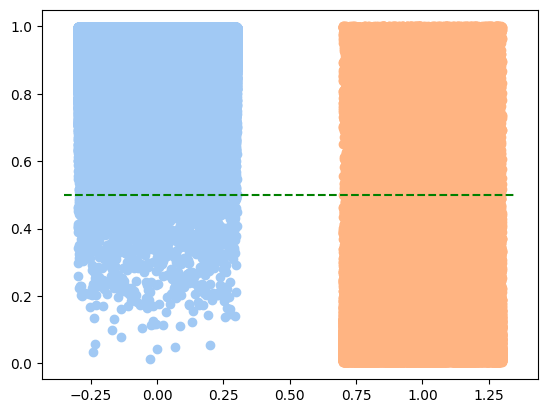

In [ ]:
plt.scatter(x = r0, y = pred_Nofraude)
plt.scatter(x = r1, y = pred_Fraude)
plt.hlines(0.5, -0.35, 1.35, color = 'g', linestyles = 'dashed')
plt.show()

In [ ]:
dt = Pipeline(steps=[
    ('transformer', transformer),
    ('classifier', DecisionTreeClassifier())
]).fit(train_data, train_label)

dt

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoding', OneHotEncoder(),
                                                  Index(['Metodo de pago', 'Categoria del producto', 'Dispositivo usado'], dtype='object')),
                                                 ('scaling', StandardScaler(),
                                                  ['Mon†o de la transaccion',
                                                   'Cantidad',
                                                   'Edad del cliente',
                                                   'Dias desde creacion de la '
                                                   'cuenta',
                                                   'Hora de la transaccion',
                                                   'Dia de la transaccion',
                                                   'Mes de la transaccion',
                                                   'Dia de la semana de la '
                                                   'transaccion',
                                                   'Coincide la direccion de '
                                                   'envio y facturacion'])])),
                ('classifier', DecisionTreeClassifier())])

In [ ]:
pred = dt.predict(test_data)
pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int8)

In [ ]:
dt_accuracy = accuracy_score(test_label, pred)
dt_accuracy

1.0

In [ ]:
dt_precision = precision_score(test_label, pred)
dt_precision

1.0

In [ ]:
dt_recall = recall_score(test_label, pred)
dt_recall

1.0

In [ ]:
dt_f1 = f1_score(test_label, pred)
dt_f1

1.0

In [ ]:
dt_report = classification_report(test_label, pred)
print(dt_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1399114
           1       1.00      1.00      1.00     73838

    accuracy                           1.00   1472952
   macro avg       1.00      1.00      1.00   1472952
weighted avg       1.00      1.00      1.00   1472952



In [ ]:
dt_cm = confusion_matrix(test_label, pred)
plot_confusion_matrix(dt_cm, ['No Fraude', 'Fraude'])

In [ ]:
TPrate = dt_cm[1,1] / (dt_cm[1,0] + dt_cm[1,1])
TPrate

np.float64(1.0)

In [ ]:
FPrate = dt_cm[0,1] / (dt_cm[0,0] + dt_cm[0,1])
FPrate

np.float64(0.0)

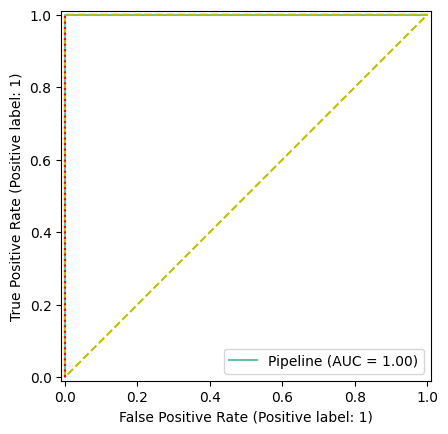

In [ ]:
RocCurveDisplay.from_estimator(dt, test_data, test_label)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

In [ ]:
rf = Pipeline(steps=[
    ('transformer', transformer),
    ('classifier', RandomForestClassifier())
]).fit(train_data, train_label)

rf

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoding', OneHotEncoder(),
                                                  Index(['Metodo de pago', 'Categoria del producto', 'Dispositivo usado'], dtype='object')),
                                                 ('scaling', StandardScaler(),
                                                  ['Mon†o de la transaccion',
                                                   'Cantidad',
                                                   'Edad del cliente',
                                                   'Dias desde creacion de la '
                                                   'cuenta',
                                                   'Hora de la transaccion',
                                                   'Dia de la transaccion',
                                                   'Mes de la transaccion',
                                                   'Dia de la semana de la '
                                                   'transaccion',
                                                   'Coincide la direccion de '
                                                   'envio y facturacion'])])),
                ('classifier', RandomForestClassifier())])

In [ ]:
rf_pred = rf.predict(test_data)
rf_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int8)

In [ ]:
rf_accuracy = accuracy_score(test_label, rf_pred)
rf_accuracy

0.999947724026309

In [ ]:
rf_precision = precision_score(test_label, rf_pred)
rf_precision

1.0

In [ ]:
rf_recall = recall_score(test_label, rf_pred)
rf_recall

0.9989571765215742

In [ ]:
rf_f1 = f1_score(test_label, rf_pred)
rf_f1

0.999478316248755

In [ ]:
rf_report = classification_report(test_label, rf_pred)
print(rf_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1399114
           1       1.00      1.00      1.00     73838

    accuracy                           1.00   1472952
   macro avg       1.00      1.00      1.00   1472952
weighted avg       1.00      1.00      1.00   1472952



In [ ]:
rf_cm = confusion_matrix(test_label, pred)
plot_confusion_matrix(lr_cm, ['No Fraude', 'Fraude'])

In [ ]:
TPrate = rf_cm[1,1] / (rf_cm[1,0] + rf_cm[1,1])
TPrate

np.float64(1.0)

In [ ]:
FPrate = rf_cm[0,1] / (rf_cm[0,0] + rf_cm[0,1])
FPrate

np.float64(0.0)

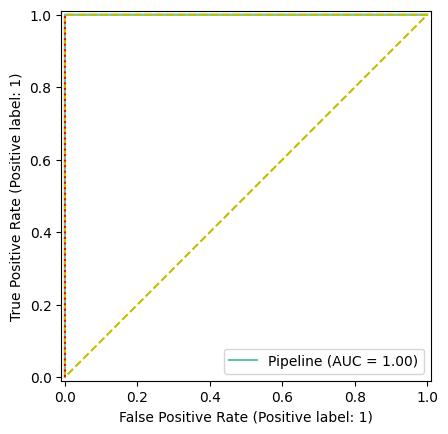

In [ ]:
RocCurveDisplay.from_estimator(rf, test_data, test_label)
plt.plot([0,0,1,0], [0,1,1,0], 'y--')
plt.plot([FPrate, FPrate], [0, TPrate], color = 'r', linestyle = 'dotted')
plt.plot([0, FPrate], [TPrate, TPrate], color = 'r', linestyle = 'dotted')
plt.show()

In [ ]:
df_fraud.columns = ['ID de la transaccion', 'ID del cliente', 'Mon†o de la transaccion', 'Fecha de la transaccion', 'Metodo de pago', 'Categoria del producto', 'Cantidad', 'Edad del cliente','Localizacion del cliente', 'Dispositivo usado', 'Direccion IP', 'Direccion de envio', 'Direccion de facturacion', '¿Es fraudulenta?','Dias desde creacion de la cuenta', 'Hora de la transaccion'] #Cambiar nombre de columnas
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Fecha de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora de la transaccion
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [ ]:
df_fraud['Fecha'] = pd.to_datetime(df_fraud['Fecha de la transaccion']).dt.date
df_fraud['Hora'] = pd.to_datetime(df_fraud['Fecha de la transaccion']).dt.time
df_fraud = df_fraud.drop('Fecha de la transaccion', axis=1)
df_fraud = df_fraud.drop('Hora de la transaccion', axis=1)

In [ ]:
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Fecha,Hora
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,2024-02-20,05:58:41
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,2024-02-25,08:09:45
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,2024-03-18,03:42:55
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,2024-03-16,20:41:31
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,2024-01-15,05:08:17


In [ ]:
df_fraud['Fecha'] = pd.to_datetime(df_fraud['Fecha'])
df_fraud['Año'] = df_fraud['Fecha'].dt.year
df_fraud['Mes'] = df_fraud['Fecha'].dt.month
df_fraud['Dia'] = df_fraud['Fecha'].dt.day
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Fecha,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,2024-02-20,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,2024-02-25,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,2024-03-18,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,2024-03-16,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,2024-01-15,05:08:17,2024,1,15


In [ ]:
df_fraud = df_fraud.drop(['Fecha'], axis=1)
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,05:08:17,2024,1,15


In [ ]:
df_fraud.describe().apply(lambda x: x.round(3)).T

,count,mean,std,min,25%,50%,75%,max
Mon†o de la transaccion,1472952.0,226.768,270.395,10.0,68.61,151.76,296.05,12701.75
Cantidad,1472952.0,3.000,1.415,1.0,2.00,3.00,4.00,5.00
Edad del cliente,1472952.0,34.512,10.003,-16.0,28.00,35.00,41.00,86.00
¿Es fraudulenta?,1472952.0,0.050,0.218,0.0,0.00,0.00,0.00,1.00
Dias desde creacion de la cuenta,1472952.0,179.646,106.864,1.0,86.00,179.00,272.00,365.00
Hora de la transaccion,1472952.0,11.287,6.976,0.0,5.00,11.00,17.00,23.00


In [ ]:
df_fraud['Año']=df_fraud['Año'].astype(object)
df_fraud['Mes']=df_fraud['Mes'].astype(object)
df_fraud['Dia']=df_fraud['Dia'].astype(object)
df_fraud.head(5)

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,05:08:17,2024,1,15


In [ ]:
df_fraud['¿Es fraudulenta?']=df_fraud['¿Es fraudulenta?'].astype(bool)
df_fraud.head(5)

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,False,30,05:58:41,2024,2,20
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",False,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",False,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",False,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",False,158,05:08:17,2024,1,15


In [ ]:
df_fraud.describe().apply(lambda x: x.round(3))

,Mon†o de la transaccion,Cantidad,Edad del cliente,Dias desde creacion de la cuenta
count,1472952.000,1472952.000,1472952.000,1472952.000
mean,226.768,3.000,34.512,179.646
std,270.395,1.415,10.003,106.864
min,10.000,1.000,-16.000,1.000
25%,68.610,2.000,28.000,86.000
50%,151.760,3.000,35.000,179.000
75%,296.050,4.000,41.000,272.000
max,12701.750,5.000,86.000,365.000


In [ ]:
df_fraud['Edad del cliente'].value_counts()

,count
Edad del cliente,
35,58910
36,58801
34,58402
33,58061
32,56964
...,...
-13,2
-10,2
-11,1


In [ ]:
mask = df_fraud['Edad del cliente'] >= 18
df_fraud = df_fraud[mask]
df_fraud.head()

,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",False,72,08:09:45,2024,2,25
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",False,63,03:42:55,2024,3,18
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",False,124,20:41:31,2024,3,16
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",False,158,05:08:17,2024,1,15
5,4e707452-7c8a-4cbd-b0c1-2aeaa35c5e88,29616b04-2d5c-4729-9c9d-8d71a6ad9dc1,166.41,bank transfer,toys & games,2,34,Herreramouth,tablet,202.237.29.55,"5699 Brittany Villages Suite 903\nLake Tim, MD...","120 Kristi Dale\nPort Meganshire, GU 03060",False,38,10:55:14,2024,1,30


In [ ]:
df_fraud.info()
df_fraud.describe().apply(lambda x: x.round(3))

<class 'pandas.core.frame.DataFrame'>
Index: 1407480 entries, 1 to 1472951
Data columns (total 18 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   ID de la transaccion              1407480 non-null  object 
 1   ID del cliente                    1407480 non-null  object 
 2   Mon†o de la transaccion           1407480 non-null  float64
 3   Metodo de pago                    1407480 non-null  object 
 4   Categoria del producto            1407480 non-null  object 
 5   Cantidad                          1407480 non-null  int64  
 6   Edad del cliente                  1407480 non-null  int64  
 7   Localizacion del cliente          1407480 non-null  object 
 8   Dispositivo usado                 1407480 non-null  object 
 9   Direccion IP                      1407480 non-null  object 
 10  Direccion de envio                1407480 non-null  object 
 11  Direccion de facturacion          1407480 

,Mon†o de la transaccion,Cantidad,Edad del cliente,Dias desde creacion de la cuenta
count,1407480.000,1407480.000,1407480.000,1407480.000
mean,226.754,3.000,35.495,179.672
std,270.434,1.415,9.075,106.872
min,10.000,1.000,18.000,1.000
25%,68.610,2.000,29.000,86.000
50%,151.770,3.000,35.000,179.000
75%,296.000,4.000,42.000,272.000
max,12701.750,5.000,86.000,365.000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_fraud.to_csv('/content/drive/MyDrive/Colab Notebooks/df_fraud.csv')

In [ ]:
df_fraud = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df_fraud.csv')
df_fraud.head(5)

,Unnamed: 0,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",False,72,08:09:45,2024,2,25
1,2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",False,63,03:42:55,2024,3,18
2,3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",False,124,20:41:31,2024,3,16
3,4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",False,158,05:08:17,2024,1,15
4,5,4e707452-7c8a-4cbd-b0c1-2aeaa35c5e88,29616b04-2d5c-4729-9c9d-8d71a6ad9dc1,166.41,bank transfer,toys & games,2,34,Herreramouth,tablet,202.237.29.55,"5699 Brittany Villages Suite 903\nLake Tim, MD...","120 Kristi Dale\nPort Meganshire, GU 03060",False,38,10:55:14,2024,1,30


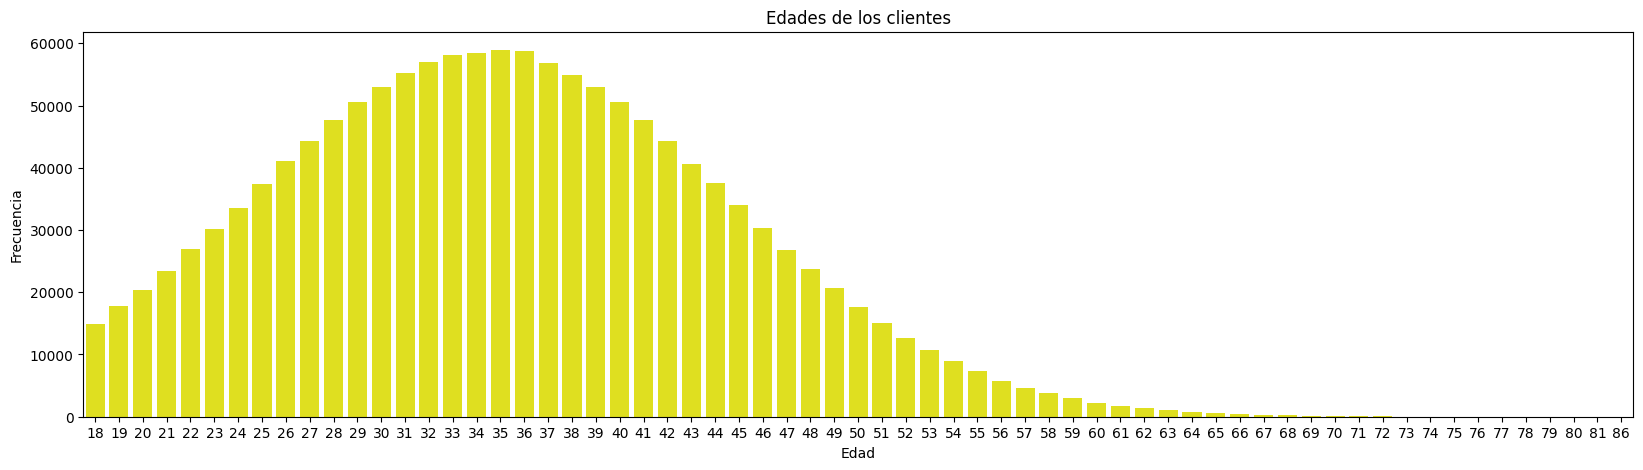

In [ ]:
plt.figure(figsize=(20,5))
sns.countplot(x='Edad del cliente', data=df_fraud, color = 'Yellow')
plt.title('Edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df_fraud.dtypes

,0
Unnamed: 0,int64
ID de la transaccion,object
ID del cliente,object
Mon†o de la transaccion,float64
Metodo de pago,object
Categoria del producto,object
Cantidad,int64
Edad del cliente,int64
Localizacion del cliente,object
Dispositivo usado,object


In [ ]:
#Veamos la diferencia entre las transacciones fraudulentas y las normales
print("Distribucion de Normal(0) y Fraudes(1): ")
print(df_fraud['¿Es fraudulenta?'].value_counts())

Distribucion de Normal(0) y Fraudes(1): 
¿Es fraudulenta?
False    1336993
True       70487
Name: count, dtype: int64


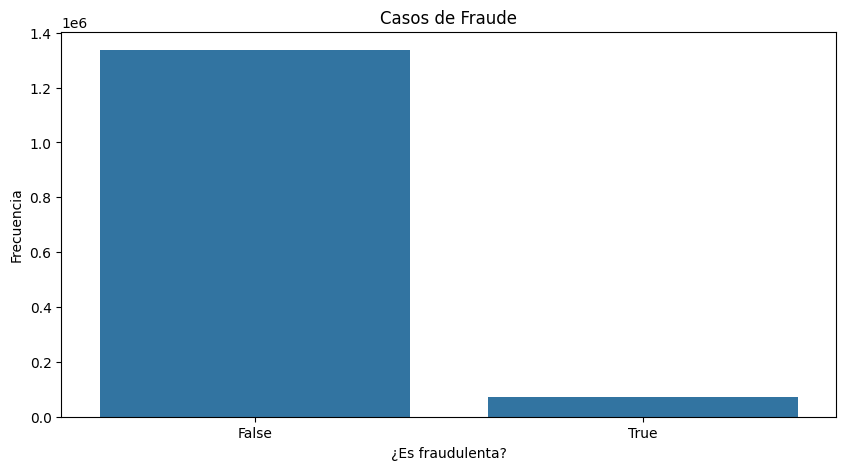

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='¿Es fraudulenta?', data=df_fraud)
plt.title('Casos de Fraude')
plt.xlabel('¿Es fraudulenta?')
plt.ylabel('Frecuencia')
plt.show()

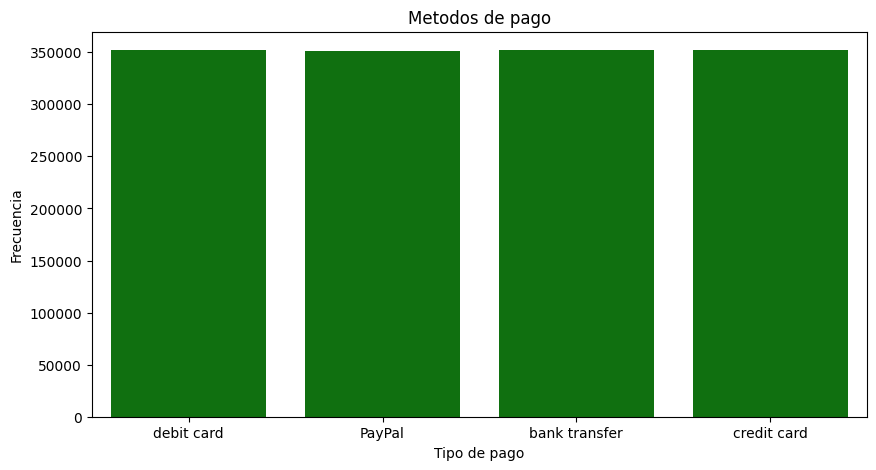

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Metodo de pago', data=df_fraud, color = 'green')
plt.title('Metodos de pago')
plt.xlabel('Tipo de pago')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
df_fraud['Metodo de pago'].value_counts()

,count
Metodo de pago,
credit card,352105
debit card,351956
bank transfer,351889
PayPal,351530


In [ ]:
df_fraud['Dispositivo usado'].value_counts()

,count
Dispositivo usado,
mobile,470056
tablet,468967
desktop,468457


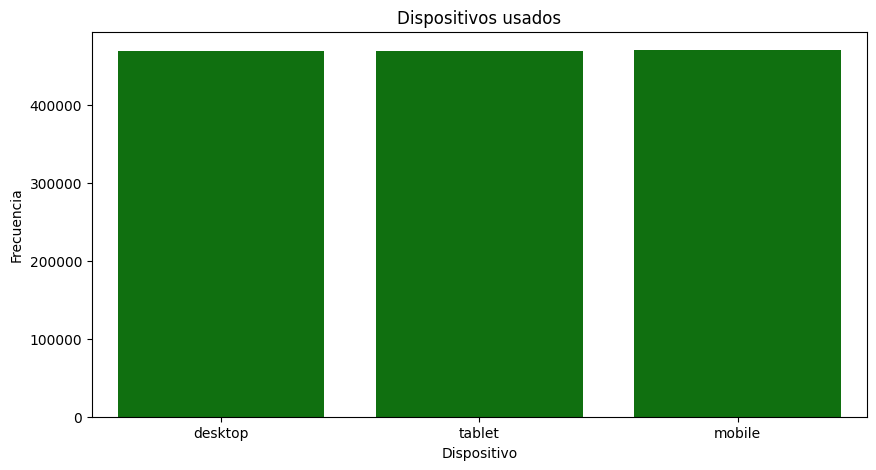

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Dispositivo usado', data=df_fraud,color = 'green')
plt.title('Dispositivos usados')
plt.xlabel('Dispositivo')
plt.ylabel('Frecuencia')
plt.show()


In [ ]:
df_fraud['Categoria del producto'].value_counts()

,count
Categoria del producto,
health & beauty,282311
electronics,282135
clothing,281289
toys & games,281000
home & garden,280745


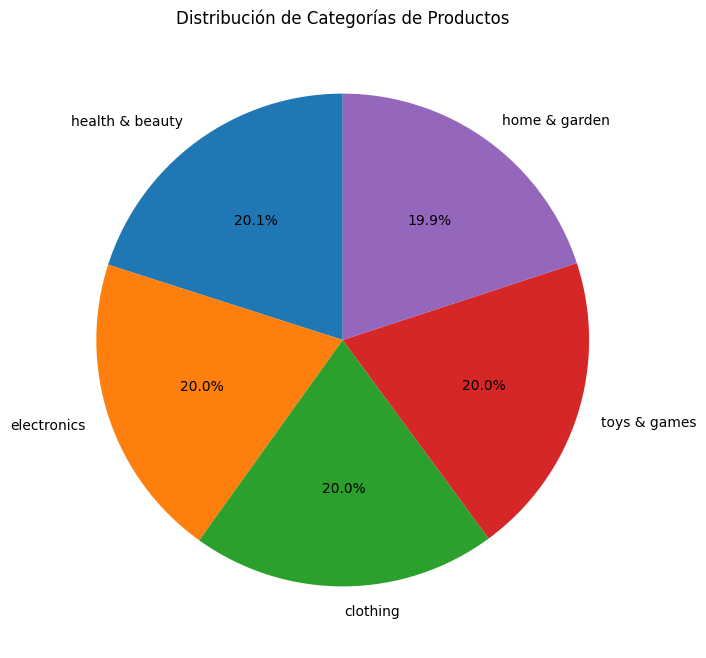

In [ ]:
import matplotlib.pyplot as plt

# Cuenta la frecuencia de cada categoría de producto
category_counts = df_fraud['Categoria del producto'].value_counts()

# Crea la gráfica de pastel
plt.figure(figsize=(8, 8))  # Ajusta el tamaño de la figura si es necesario
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Categorías de Productos')
plt.show()

In [ ]:
df_fraud['Mon†o de la transaccion'].describe().round(3)

,Mon†o de la transaccion
count,1407480.000
mean,226.754
std,270.434
min,10.000
25%,68.610
50%,151.770
75%,296.000
max,12701.750


<ipython-input-42-dcb38b0bf20c>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fraudes['Mon†o de la transaccion'], color='red', label='Fraudes')
<ipython-input-42-dcb38b0bf20c>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(no_fraudes['Mon†o de la transaccion'], color='green', label='No Frau

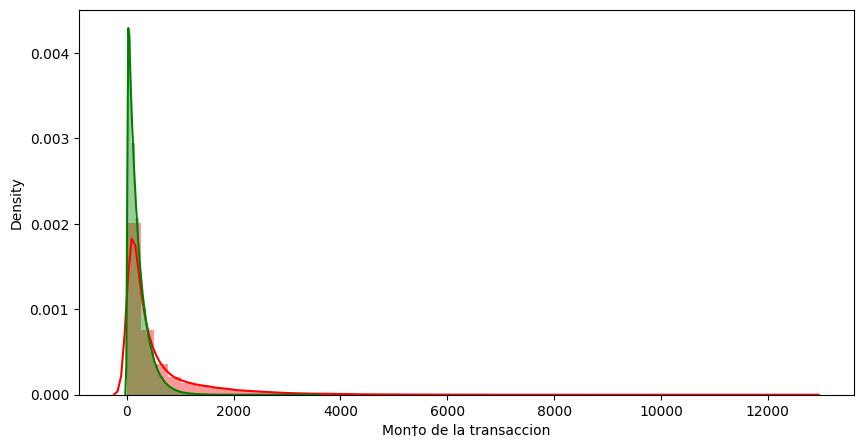

In [ ]:
fraudes = df_fraud[df_fraud['¿Es fraudulenta?'] == True]
no_fraudes = df_fraud[df_fraud['¿Es fraudulenta?'] == False]

plt.figure(figsize=(10,5))
sns.distplot(fraudes['Mon†o de la transaccion'], color='red', label='Fraudes')
sns.distplot(no_fraudes['Mon†o de la transaccion'], color='green', label='No Fraudes')
plt.show()

In [ ]:
total_por_categoria = df_fraud['Categoria del producto'].value_counts()
fraudes_por_categoria = df_fraud[df_fraud['¿Es fraudulenta?'] == True]['Categoria del producto'].value_counts()

porcentaje_fraudes_por_categoria = ((fraudes_por_categoria / total_por_categoria) * 100).sort_values(ascending=False)
print(porcentaje_fraudes_por_categoria)

Categoria del producto
toys & games       5.040925
clothing           5.034680
home & garden      5.013446
health & beauty    5.000868
electronics        4.950467
Name: count, dtype: float64


<Axes: xlabel='Categoria del producto', ylabel='count'>

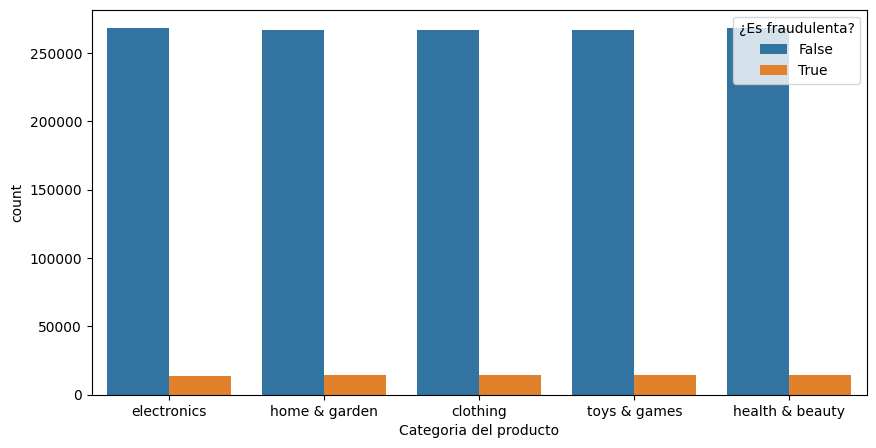

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Categoria del producto', data=df_fraud, hue='¿Es fraudulenta?')

In [ ]:
df_fraud['Año']=df_fraud['Año'].astype(object)
df_fraud['Mes']=df_fraud['Mes'].astype(object)
df_fraud['Dia']=df_fraud['Dia'].astype(object)
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407480 entries, 0 to 1407479
Data columns (total 19 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   Unnamed: 0                        1407480 non-null  int64  
 1   ID de la transaccion              1407480 non-null  object 
 2   ID del cliente                    1407480 non-null  object 
 3   Mon†o de la transaccion           1407480 non-null  float64
 4   Metodo de pago                    1407480 non-null  object 
 5   Categoria del producto            1407480 non-null  object 
 6   Cantidad                          1407480 non-null  int64  
 7   Edad del cliente                  1407480 non-null  int64  
 8   Localizacion del cliente          1407480 non-null  object 
 9   Dispositivo usado                 1407480 non-null  object 
 10  Direccion IP                      1407480 non-null  object 
 11  Direccion de envio                140

In [ ]:
# Para elementos numericos
numeric_features = df_fraud.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = numeric_features.corr()

# Display the correlation matrix
corr_matrix

,Unnamed: 0,Mon†o de la transaccion,Cantidad,Edad del cliente,Dias desde creacion de la cuenta
Unnamed: 0,1.000000,-0.000019,0.000316,-0.000150,-0.000487
Mon†o de la transaccion,-0.000019,1.000000,-0.000686,0.000505,-0.035707
Cantidad,0.000316,-0.000686,1.000000,0.000420,0.001244
Edad del cliente,-0.000150,0.000505,0.000420,1.000000,-0.000013
Dias desde creacion de la cuenta,-0.000487,-0.035707,0.001244,-0.000013,1.000000


<Axes: >

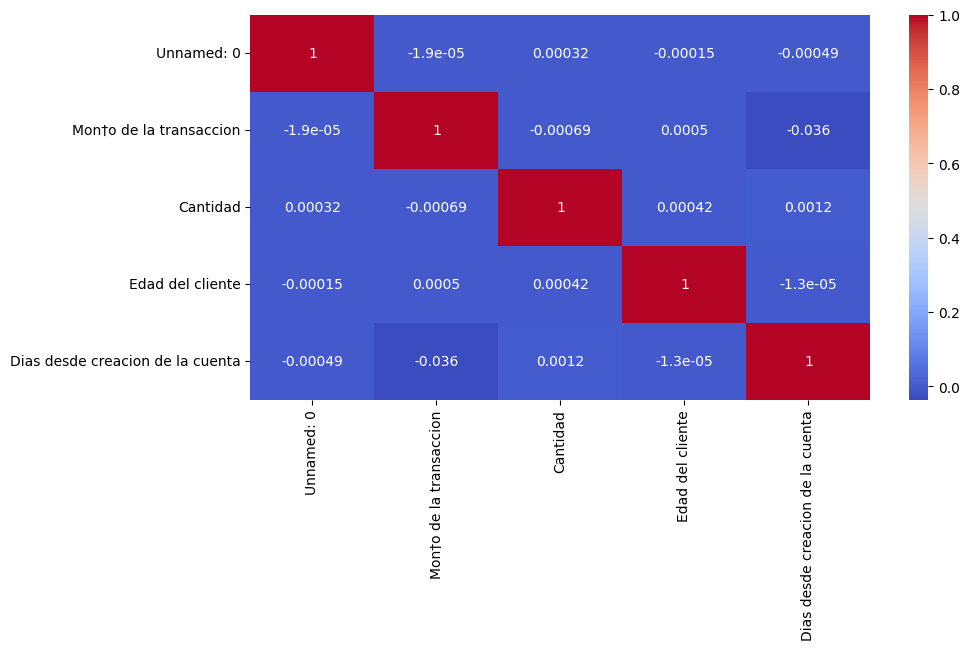

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [ ]:
df_fraud = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df_fraud.csv')
df_fraud.head(5)

,Unnamed: 0,ID de la transaccion,ID del cliente,Mon†o de la transaccion,Metodo de pago,Categoria del producto,Cantidad,Edad del cliente,Localizacion del cliente,Dispositivo usado,Direccion IP,Direccion de envio,Direccion de facturacion,¿Es fraudulenta?,Dias desde creacion de la cuenta,Hora,Año,Mes,Dia
0,1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",False,72,08:09:45,2024,2,25
1,2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",False,63,03:42:55,2024,3,18
2,3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",False,124,20:41:31,2024,3,16
3,4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",False,158,05:08:17,2024,1,15
4,5,4e707452-7c8a-4cbd-b0c1-2aeaa35c5e88,29616b04-2d5c-4729-9c9d-8d71a6ad9dc1,166.41,bank transfer,toys & games,2,34,Herreramouth,tablet,202.237.29.55,"5699 Brittany Villages Suite 903\nLake Tim, MD...","120 Kristi Dale\nPort Meganshire, GU 03060",False,38,10:55:14,2024,1,30


In [ ]:
df_fraud['Dias desde creacion de la cuenta'].value_counts()

,count
Dias desde creacion de la cuenta,
11,4867
21,4827
15,4819
18,4808
9,4805
...,...
300,3637
125,3632
271,3627


In [ ]:
df_fraud['Dias desde creacion de la cuenta'].describe().round(3)

,Dias desde creacion de la cuenta
count,1407480.000
mean,179.672
std,106.872
min,1.000
25%,86.000
50%,179.000
75%,272.000
max,365.000


<Axes: >

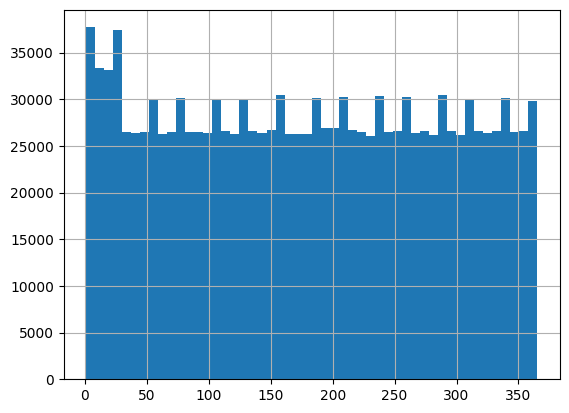

In [ ]:
df_fraud['Dias desde creacion de la cuenta'].hist(bins=50)

<Axes: >

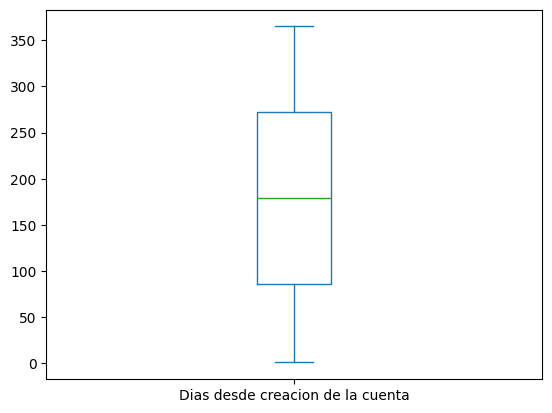

In [ ]:
df_fraud['Dias desde creacion de la cuenta'].plot(kind='box')

<Axes: ylabel='Density'>

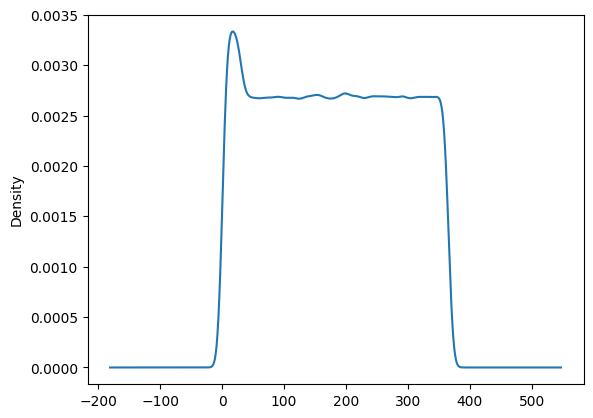

In [ ]:
df_fraud['Dias desde creacion de la cuenta'].plot(kind='density')

In [ ]:
df_fraud['Tipo de cliente'] = pd.cut(df_fraud['Dias desde creacion de la cuenta'],bins=[0,60,float('inf')],labels=['Nuevo','Antiguo'])

In [ ]:
fraude_rate = df_fraud.groupby('Tipo de cliente')['¿Es fraudulenta?'].mean()*100
print(fraude_rate)

Tipo de cliente
Nuevo      13.814996
Antiguo     3.062302
Name: ¿Es fraudulenta?, dtype: float64


<ipython-input-18-c5eb4e513ca5>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraude_rate = df_fraud.groupby('Tipo de cliente')['¿Es fraudulenta?'].mean()*100


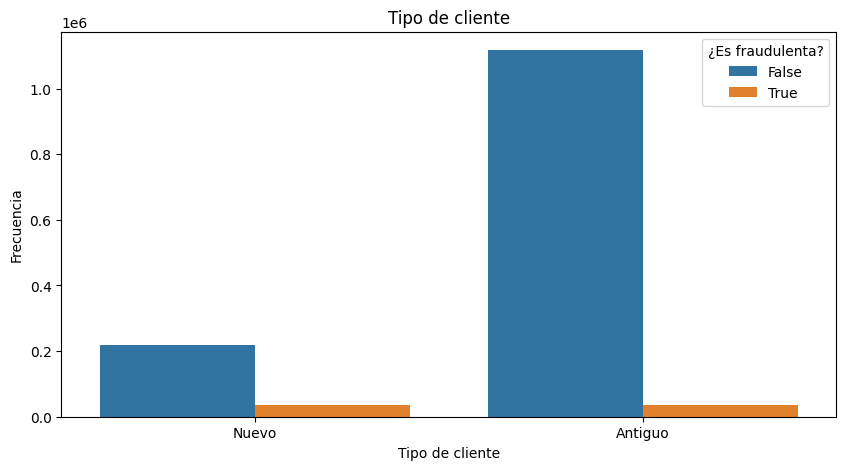

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Tipo de cliente', data=df_fraud, hue='¿Es fraudulenta?')
plt.title('Tipo de cliente')
plt.xlabel('Tipo de cliente')
plt.ylabel('Frecuencia')
plt.show()

<Axes: xlabel='Tipo de cliente', ylabel='Dias desde creacion de la cuenta'>

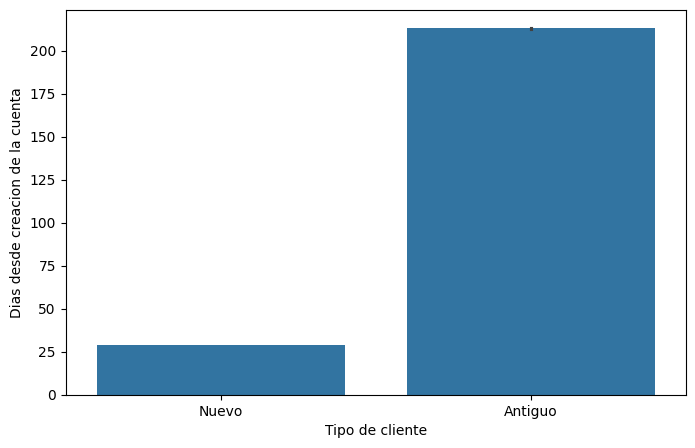

In [ ]:
# @title
plt.figure(figsize=(8,5))
sns.barplot(x='Tipo de cliente', y='Dias desde creacion de la cuenta', data=df_fraud)

<Axes: xlabel='Dias desde creacion de la cuenta', ylabel='Count'>

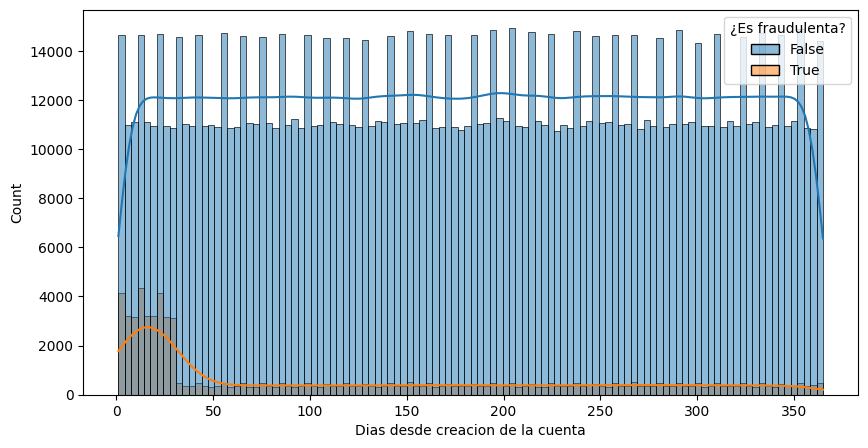

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(data=df_fraud, x='Dias desde creacion de la cuenta', hue='¿Es fraudulenta?', kde=True)
